<a href="https://colab.research.google.com/github/mahi0532/ML_case_study2/blob/main/CASE_STUDY_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Before SMOTE - Fraud cases in train: 189
After SMOTE  - Fraud cases in train: 6936

--- Model Performance ---
ROC-AUC Score: 0.8978600772579558

Confusion Matrix:
[[1726    9]
 [  24   23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1735
           1       0.72      0.49      0.58        47

    accuracy                           0.98      1782
   macro avg       0.85      0.74      0.79      1782
weighted avg       0.98      0.98      0.98      1782



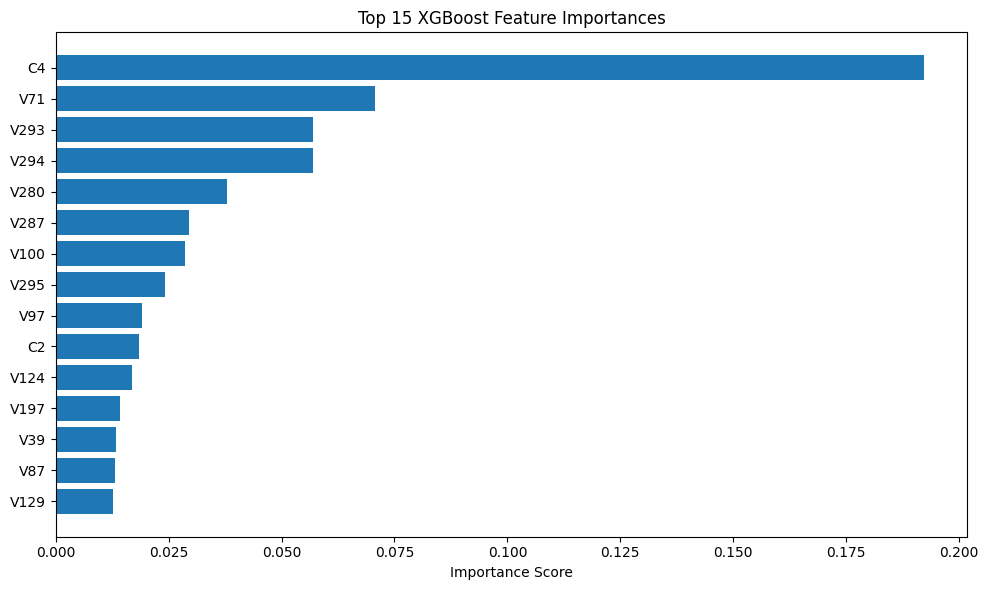

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv('train_transaction.csv')

X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 1. Keep only numeric columns (drops text/categorical data)
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

# 2. Fill any missing values with 0
X_train_clean = X_train_num.fillna(0)
X_test_clean = X_test_num.fillna(0)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

print(f"Before SMOTE - Fraud cases in train: {sum(y_train == 1)}")
print(f"After SMOTE  - Fraud cases in train: {sum(y_train_smote == 1)}")

model = XGBClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

# Get probabilities for the fraud class (1)
y_prob = model.predict_proba(X_test_clean)[:, 1]

# Default threshold is 0.5, but for fraud, we lower it (e.g., 0.3)
# to catch more fraud cases and avoid missing dangerous transactions.
custom_threshold = 0.3
y_pred_tuned = (y_prob >= custom_threshold).astype(int)

print("\n--- Model Performance ---")
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# --- FIX: use X_train_clean (what the model was actually trained on),
# not the original X, since X still has the dropped categorical columns.
# X.shape[1] != len(model.feature_importances_), which caused a mismatch.
importances = model.feature_importances_
feature_names = X_train_clean.columns

# Sort and keep only the top 15 features so the chart stays readable
# (the full IEEE-CIS dataset has 300+ numeric columns).
top_n = 15
sorted_idx = importances.argsort()[::-1][:top_n]

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in sorted_idx][::-1],
    importances[sorted_idx][::-1]
)
plt.xlabel("Importance Score")
plt.title(f"Top {top_n} XGBoost Feature Importances")
plt.tight_layout()
plt.show()